## Lineaer versus Mulitple Linear Regression

* Muliple predictors are available to predict the target.
* Model estimates coeeficients for each predictor. 
* Predictors can overalapp, creating potential mulitcollinearity problem

Predicted CO₂ = Intercept + (b₁ × Engine Size) + (b₂ × Cylinders) + (b₃ × Fuel Consumption)

In [1]:
#Import
import pandas as pd
from sklearn import linear_model

In [2]:
#File loading
df = pd.read_csv("cars.csv")

**Modelling Linear Regression:** 

* Select X and y
* train/test split
* fit on training data
* predict test data
* evaluate performance

In [3]:
# Model Training
X = df[['Weight', 'Volume']]
y = df['CO2']

regr = linear_model.LinearRegression()
regr.fit(X, y) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
#Predict the CO2 emission of a car where the weight is 2300kg, and the volume is 1300cm3:

new_car = pd.DataFrame({'Weight': [2300], 'Volume': [1300]})

predictedCO2 = regr.predict(new_car)

print('CO2 prediction:', predictedCO2)

CO2 prediction: [107.2087328]


## Coefficient

The coefficient is a factor that describes the relationship with an unknown variable.
In this case, we can ask for the coefficient value of weight against CO2, and for volume against CO2. The answer(s) we get tells us what would happen if we increase, or decrease, one of the independent values.

In [15]:
print(regr.coef_)

[0.00755095 0.00780526]


In [16]:
print(regr.intercept_)

79.69471929115937


The result array represents the coefficient values of weight and volume.

* Weight: 0.00755095
* Volume: 0.00780526

These values tell us that: 
* if the weight increase by 1kg, the CO2 emission increases by 0.00755095g.
* if the engine size (Volume) increases by 1 cm3, the CO2 emission increases by 0.00780526 g.

We have already predicted that if a car with a 1300cm3 engine weighs 2300kg, the CO2 emission will be approximately 107g.
What if we increase the weight with 1000kg (from 2300 to 3300) what will be the CO2 emission?

Ans: 107.2087328 + (1000 * 0.00755095) = 114.75968

## Additional Exercise
Define X/y → create LinearRegression() → .fit() → inspect coefficients → .predict()

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [50]:
data = {

    'age': [2, 5, 3, 8, 6, 1, 10, 4, 7, 3, 9, 5],
    'km_driven': [25000, 70000, 42000, 120000, 85000, 15000, 145000, 55000, 100000, 35000, 130000, 65000
    ],
    'engine': [1500, 1200, 1600, 1200, 1400, 2000, 1200, 1800, 1300, 1600, 1500, 1400
    ],
    'selling_price': [18500, 10500, 16000, 5500, 8500, 26000, 4000, 17000, 7000, 17500, 6000, 11500
    ]

}

df = pd.DataFrame(data)
df

,age,km_driven,engine,selling_price
0,2,25000,1500,18500
1,5,70000,1200,10500
2,3,42000,1600,16000
3,8,120000,1200,5500
4,6,85000,1400,8500
5,1,15000,2000,26000
6,10,145000,1200,4000
7,4,55000,1800,17000
8,7,100000,1300,7000
9,3,35000,1600,17500


In [51]:
# 1. Define predictors and target
X = df[['age','km_driven','engine']]
y = df['selling_price']

In [52]:
#check the predictors
X.head()

,age,km_driven,engine
0,2,25000,1500
1,5,70000,1200
2,3,42000,1600
3,8,120000,1200
4,6,85000,1400


In [53]:
from sklearn.linear_model import LinearRegression

# 2. Create a regresssion model
model = LinearRegression()

# 3. Fit model
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [54]:
# Inspect coefficients
pd.DataFrame({
    'Coefficient': model.coef_},
             index=X.columns)

,Coefficient
age,-2852.992795
km_driven,0.081650
engine,9.746419


In [55]:
pd.DataFrame({'Intercept': [model.intercept_]})

,Intercept
0,6900.249933


Interpretation: 
Holding the other predictors constant, 
* One additional year of age is associated with approximately €2853 lower predicted selling price.
* One additional 1000km driven is associated with approximately €80 higher predicted selling price.
* One additional cc of engine is associated with approximately €10 higher predicted selling price.

Observation: higher mileage lead to slighly higher price?

In [56]:
# predict new vehicle
new_car = pd.DataFrame({
    'age': [4],
    'km_driven': [5000],
    'engine': [1500],
})

predicted_price = model.predict(new_car)
print('Predicted selling price:', predicted_price[0])

Predicted selling price: 10516.159468793248


In [57]:
# predicted model
selling_price_predicted = model.predict(X)


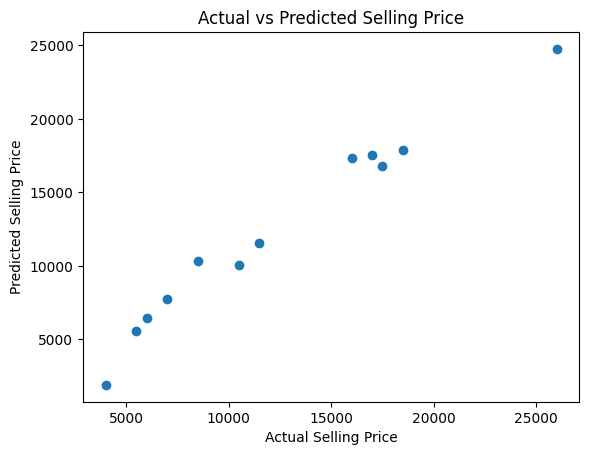

In [58]:
# Actual price vs predicted price
plt.scatter(y, selling_price_predicted)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price')
plt.show()


## Evalaution with Train Test split


In [65]:
#Train Test split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [66]:
# 1. Define X and y

X = df[["age", "km_driven", "engine"]]
y = df["selling_price"]

In [67]:
# 2. Split the existing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [68]:
# 3. Create a NEW model
model = LinearRegression()

In [69]:
# 4. Train it ONLY on training data
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [70]:
# 5. Predict the unseen test data
y_pred = model.predict(X_test)